<a href="https://colab.research.google.com/github/August0-mp/music-genre-classifier/blob/main/sound_wave_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sound Wave Study

In [ ]:
!kaggle datasets list -s tinysol

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
thedevastator/tinysol-isolated-musical-notes-from-14-musical-i       TinySOL: Isolated musical notes audio dataset            25829  2023-01-03 10:08:26.847000            362          8  0.9411765        
desolationofsmaug/violin-vs-cello-musical-instrument-classification  Violin vs Cello: Musical Instrument Classification   254443087  2024-05-13 05:45:18.053000            104          2  0.7647059        


## Libs

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as skt
import torch
import torchaudio
import librosa
import IPython.display as ipd
import librosa.display

## Dataset

### Load the data

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("desolationofsmaug/violin-vs-cello-musical-instrument-classification")

print("Path to dataset files:", path)

100%|██████████| 243M/243M [00:01<00:00, 135MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/desolationofsmaug/violin-vs-cello-musical-instrument-classification/versions/1


## Spectrogram

In [45]:
def plot_spectogram(data, sample_rate):
    data_stft = librosa.stft(data)
    data_stft_db = librosa.amplitude_to_db(np.abs(data_stft), ref=np.max)

    fig, ax = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=(10, 8),
        constrained_layout=True
    )

    img1 = librosa.display.specshow(
        data_stft_db,
        y_axis='linear',
        x_axis='time',
        sr=sample_rate,
        ax=ax[0],
    )
    ax[0].set_ylim(0, 5000)
    ax[0].set_title('Linear-frequency power spectrogram')

    img2 = librosa.display.specshow(
        data_stft_db,
        y_axis='log',
        x_axis='time',
        sr=sample_rate,
        ax=ax[1],
        fmin=200,
        fmax=8000
    )
    ax[1].set_title('Log-frequency power spectrogram')

    fig.colorbar(
        img2,
        ax=ax,
        format='%+2.0f dB'
    )

    plt.show()

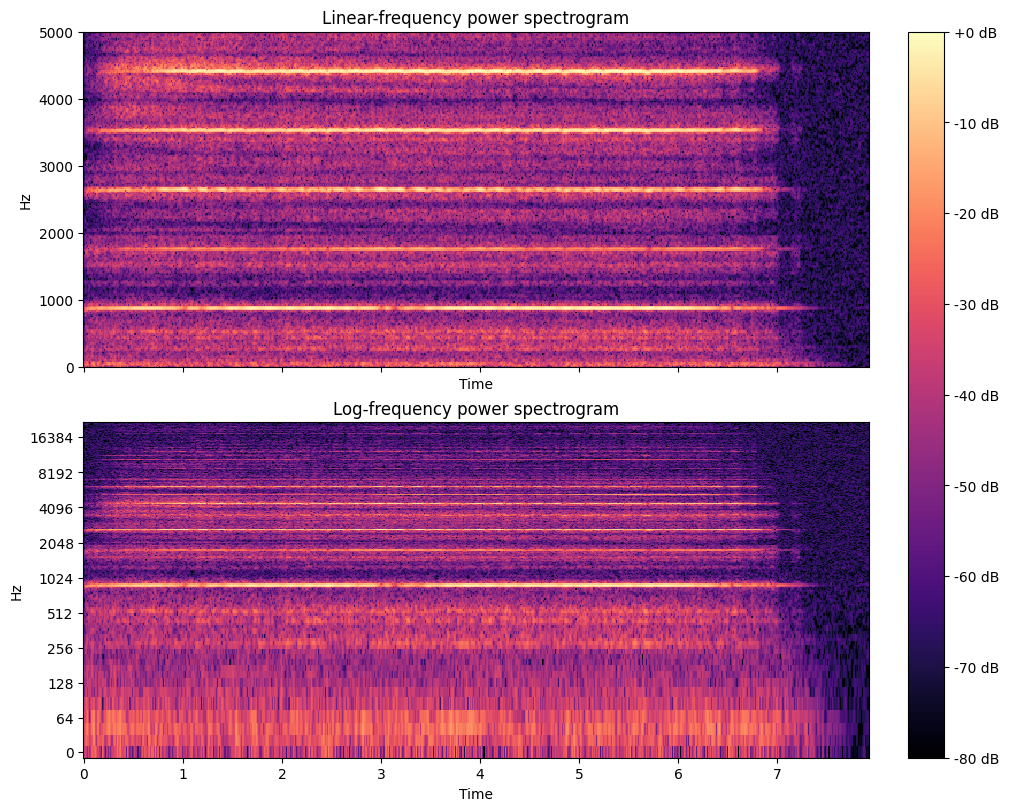

In [46]:
y, sr = librosa.load(path+"/Violin/ordinario/Vn-ord-A5-pp-1c-N.wav", sr=None)
plot_spectogram(y, sr)

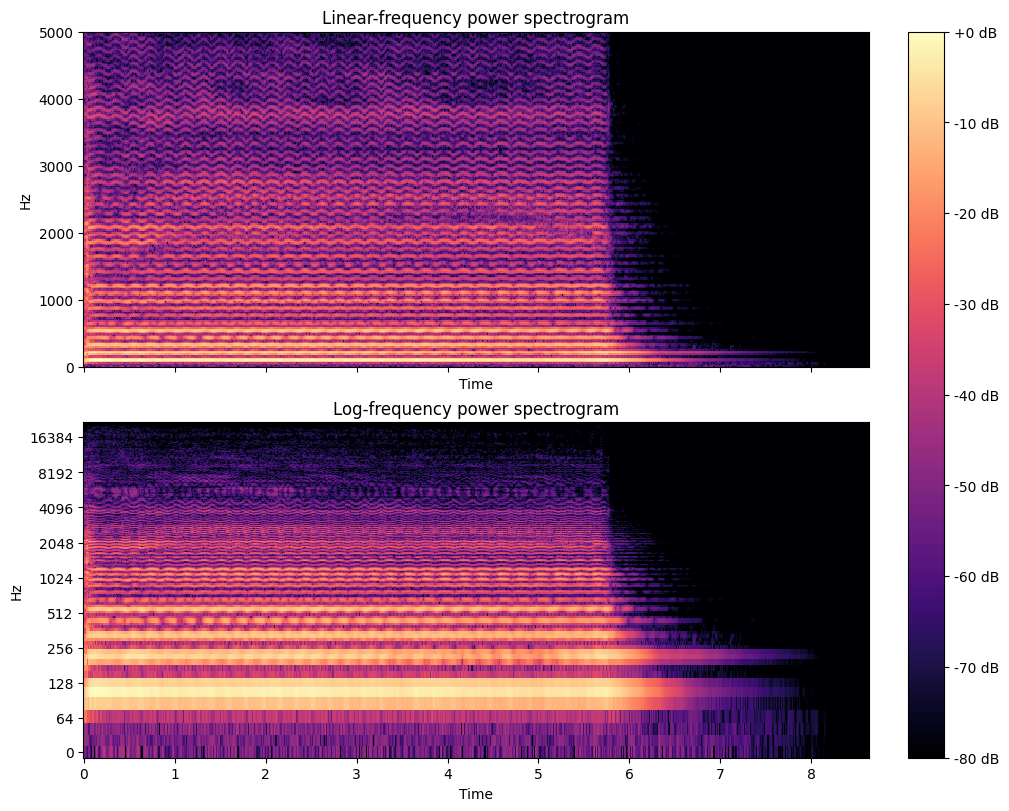

In [47]:
y, sr = librosa.load(path+"/Cello/ordinario/Vc-ord-A2-ff-3c-T19d.wav", sr=None)
plot_spectogram(y, sr)

Here we can clearly see the harmonic partials. Observe that the energy of the violin is more concentrated than that the cello energy that is distributed between the other partials.